In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs found:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✅ GPU е наличен и memory growth е включен.")
else:
    print("❌ TensorFlow не вижда GPU. Ще тренира на CPU.")

TensorFlow version: 2.10.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU е наличен и memory growth е включен.


In [2]:
DATASET_CSV = r"D:\Магистър\Общ проект\dataset_mri_pet_labels.csv"

dataset_df = pd.read_csv(DATASET_CSV)

print("Dataset shape:", dataset_df.shape)
display(dataset_df.head())

print("Разпределение по диагноза:")
print(dataset_df["diagnosis"].value_counts())

Dataset shape: (458, 5)


,subject_id,mri_path,pet_path,diagnosis,label
0,002_S_0295,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
1,002_S_0413,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
2,002_S_0685,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
3,002_S_1261,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0
4,002_S_1280,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,D:\Магистър\Общ проект\ADNI_tensors_complete\0...,CN,0


Разпределение по диагноза:
diagnosis
CN    311
AD    147
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    dataset_df,
    test_size=0.20,
    random_state=42,
    stratify=dataset_df["label"]
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.20,
    random_state=42,
    stratify=train_val_df["label"]
)

print("Train:", len(train_df))
print(train_df["diagnosis"].value_counts())
print()

print("Validation:", len(val_df))
print(val_df["diagnosis"].value_counts())
print()

print("Test:", len(test_df))
print(test_df["diagnosis"].value_counts())

Train: 292
diagnosis
CN    199
AD     93
Name: count, dtype: int64

Validation: 74
diagnosis
CN    50
AD    24
Name: count, dtype: int64

Test: 92
diagnosis
CN    62
AD    30
Name: count, dtype: int64


In [4]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])  # CN = 0, AD = 1

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    0: class_weights_values[0],
    1: class_weights_values[1]
}

print("Class weights:", class_weights)

Class weights: {0: 0.7336683417085427, 1: 1.5698924731182795}


In [5]:
import tensorflow as tf
import numpy as np

BATCH_SIZE = 1
INPUT_SHAPE = (64, 64, 64, 2)

def downsample_volume(volume):
    """
    Намалява 128x128x128 до 64x64x64 чрез вземане на всяка втора стойност.
    """
    return volume[::2, ::2, ::2]

def load_sample(mri_path, pet_path, label):
    mri_path = mri_path.decode("utf-8")
    pet_path = pet_path.decode("utf-8")

    mri = np.load(mri_path).astype("float32")
    pet = np.load(pet_path).astype("float32")

    mri = downsample_volume(mri)
    pet = downsample_volume(pet)

    # MRI и PET като два канала
    x = np.stack([mri, pet], axis=-1)

    y = np.float32(label)

    return x, y

def tf_load_sample(mri_path, pet_path, label):
    x, y = tf.numpy_function(
        load_sample,
        [mri_path, pet_path, label],
        [tf.float32, tf.float32]
    )

    x.set_shape(INPUT_SHAPE)
    y.set_shape(())

    return x, y

def make_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["mri_path"].values,
        df["pet_path"].values,
        df["label"].values.astype("float32")
    ))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=42,
            reshuffle_each_iteration=True
        )

    ds = ds.map(tf_load_sample, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("✅ TensorFlow datasets са готови.")

for x_batch, y_batch in train_ds.take(1):
    print("X batch shape:", x_batch.shape)
    print("Y batch shape:", y_batch.shape)

✅ TensorFlow datasets са готови.
X batch shape: (1, 64, 64, 64, 2)
Y batch shape: (1,)


In [6]:
import tensorflow as tf

def binary_focal_loss(gamma=2.0, alpha=0.65):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        bce = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        modulating_factor = tf.pow(1.0 - p_t, gamma)

        return tf.reduce_mean(alpha_factor * modulating_factor * bce)

    return loss

In [7]:
from tensorflow.keras import layers, models, regularizers

def build_stable_3d_cnn(input_shape=(64, 64, 64, 2)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv3D(8, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling3D(2)(x)

    x = layers.Conv3D(16, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling3D(2)(x)

    x = layers.Conv3D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling3D(2)(x)

    x = layers.Conv3D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling3D()(x)

    x = layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name="Model_Stable_3D_CNN_FocalLoss")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
        loss=binary_focal_loss(gamma=2.0, alpha=0.65),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="sensitivity"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

model_stable = build_stable_3d_cnn()
model_stable.summary()

Model: "Model_Stable_3D_CNN_FocalLoss"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 64, 2)]   0         
                                                                 
 conv3d (Conv3D)             (None, 64, 64, 64, 8)     432       
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 64, 8)    32        
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 64, 64, 64, 8)     0         
                                                                 
 max_pooling3d (MaxPooling3D  (None, 32, 32, 32, 8)    0         
 )                                                               
                                                                 
 conv3d_1 (Conv3D)           (None, 3

In [8]:
callbacks_stable = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "model_stable_3d_cnn_focal.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

In [9]:
history_stable = model_stable.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks_stable
)

Epoch 1/40
291/292 [============================>.] - ETA: 0s - loss: 0.0887 - accuracy: 0.4948 - precision: 0.3071 - sensitivity: 0.4624 - auc: 0.4812
Epoch 1: val_auc improved from -inf to 0.37125, saving model to model_stable_3d_cnn_focal.keras
292/292 [==============================] - 15s 37ms/step - loss: 0.0885 - accuracy: 0.4966 - precision: 0.3071 - sensitivity: 0.4624 - auc: 0.4834 - val_loss: 0.0878 - val_accuracy: 0.6757 - val_precision: 0.0000e+00 - val_sensitivity: 0.0000e+00 - val_auc: 0.3712 - lr: 3.0000e-05
Epoch 2/40
292/292 [==============================] - ETA: 0s - loss: 0.0848 - accuracy: 0.5171 - precision: 0.3182 - sensitivity: 0.4516 - auc: 0.5166
Epoch 2: val_auc improved from 0.37125 to 0.40125, saving model to model_stable_3d_cnn_focal.keras
292/292 [==============================] - 10s 34ms/step - loss: 0.0848 - accuracy: 0.5171 - precision: 0.3182 - sensitivity: 0.4516 - auc: 0.5166 - val_loss: 0.0866 - val_accuracy: 0.6757 - val_precision: 0.0000e+00 - 

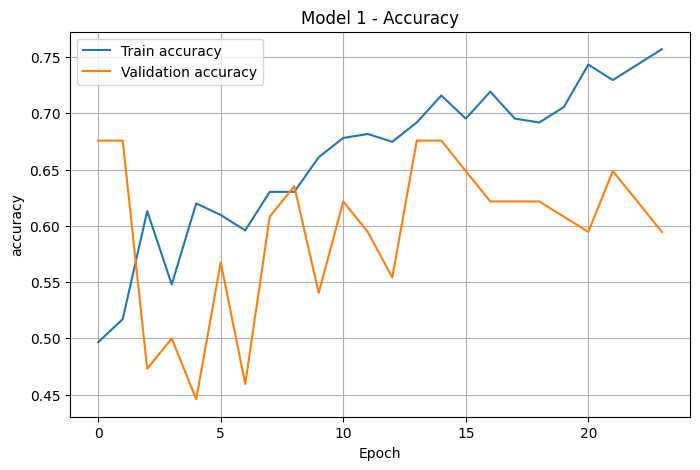

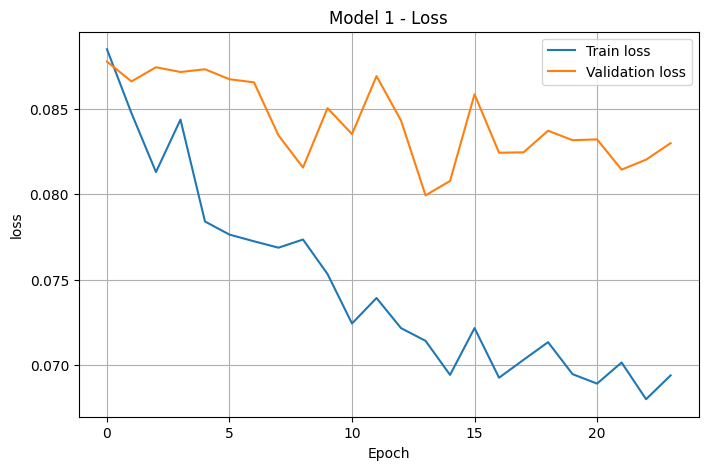

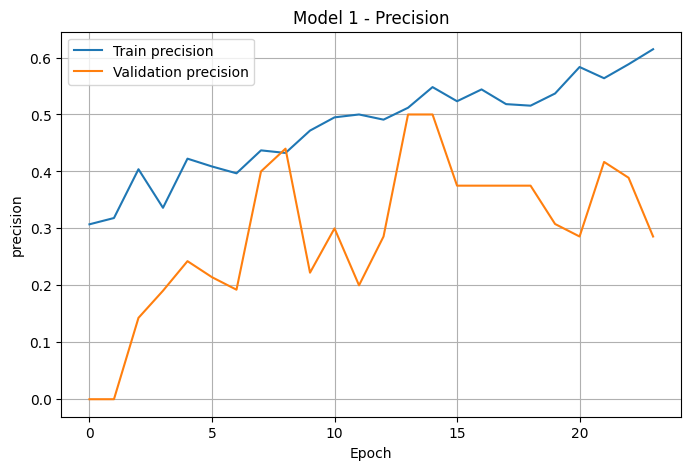

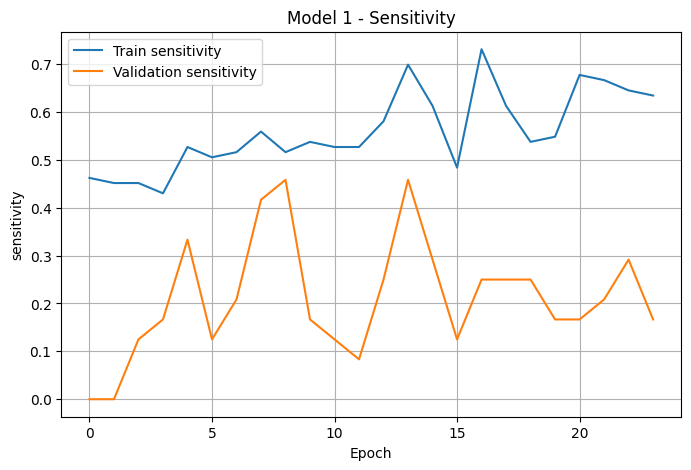

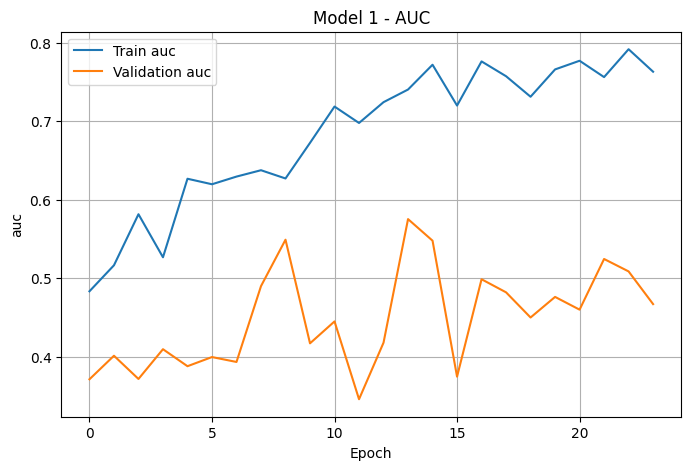

In [11]:
import matplotlib.pyplot as plt

def plot_metric(history, metric, title, filename):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history[metric], label=f"Train {metric}")
    plt.plot(history.history[f"val_{metric}"], label=f"Validation {metric}")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

plot_metric(history_stable, "accuracy", "Model 1 - Accuracy", "model1_accuracy.png")
plot_metric(history_stable, "loss", "Model 1 - Loss", "model1_loss.png")
plot_metric(history_stable, "precision", "Model 1 - Precision", "model1_precision.png")
plot_metric(history_stable, "sensitivity", "Model 1 - Sensitivity", "model1_sensitivity.png")
plot_metric(history_stable, "auc", "Model 1 - AUC", "model1_auc.png")

In [12]:
test_results_stable = model_stable.evaluate(test_ds, verbose=1)

print("Stable Model Test results:")
for name, value in zip(model_stable.metrics_names, test_results_stable):
    print(f"{name}: {value:.4f}")

92/92 [==============================] - 2s 18ms/step - loss: 0.0813 - accuracy: 0.5978 - precision: 0.3793 - sensitivity: 0.3667 - auc: 0.5524
Stable Model Test results:
loss: 0.0813
accuracy: 0.5978
precision: 0.3793
sensitivity: 0.3667
auc: 0.5524


In [14]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

y_true = []
y_prob = []

for x_batch, y_batch in test_ds:
    preds = model_stable.predict(x_batch, verbose=0)
    y_prob.extend(preds.ravel())
    y_true.extend(y_batch.numpy().ravel())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

thresholds = np.arange(0.30, 0.71, 0.05)

rows = []

for th in thresholds:
    y_pred = (y_prob >= th).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )

    acc = accuracy_score(y_true, y_pred)

    rows.append({
        "threshold": round(th, 2),
        "accuracy": acc,
        "precision": precision,
        "sensitivity": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df.sort_values("f1", ascending=False))

,threshold,accuracy,precision,sensitivity,f1
0,0.30,0.326087,0.326087,1.000000,0.491803
1,0.35,0.326087,0.326087,1.000000,0.491803
2,0.40,0.336957,0.321839,0.933333,0.478632
3,0.45,0.391304,0.314286,0.733333,0.440000
4,0.50,0.597826,0.379310,0.366667,0.372881
5,0.55,0.673913,0.500000,0.033333,0.062500
6,0.60,0.673913,0.000000,0.000000,0.000000
7,0.65,0.673913,0.000000,0.000000,0.000000
8,0.70,0.673913,0.000000,0.000000,0.000000


Stable Model Confusion Matrix:
[[44 18]
 [19 11]]

TN: 44
FP: 18
FN: 19
TP: 11

              precision    recall  f1-score   support

          CN       0.70      0.71      0.70        62
          AD       0.38      0.37      0.37        30

    accuracy                           0.60        92
   macro avg       0.54      0.54      0.54        92
weighted avg       0.59      0.60      0.60        92



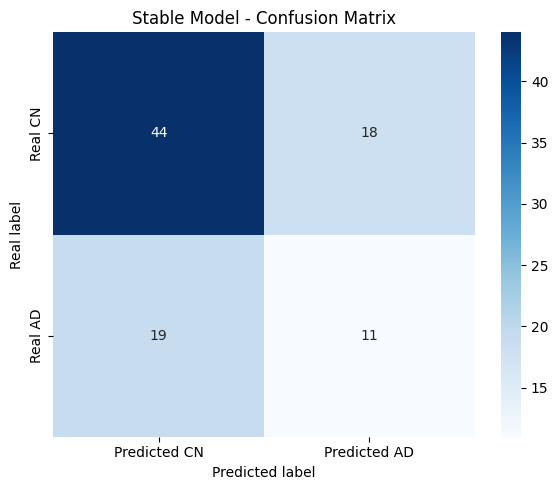

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ако вече имаш y_true и y_prob от stable модела:
# избираме threshold, например 0.50
threshold = 0.50

y_pred_stable = (y_prob >= threshold).astype(int)

cm_stable = confusion_matrix(y_true, y_pred_stable)

tn_stable, fp_stable, fn_stable, tp_stable = cm_stable.ravel()

print("Stable Model Confusion Matrix:")
print(cm_stable)
print()
print(f"TN: {tn_stable}")
print(f"FP: {fp_stable}")
print(f"FN: {fn_stable}")
print(f"TP: {tp_stable}")
print()

print(classification_report(
    y_true,
    y_pred_stable,
    target_names=["CN", "AD"],
    zero_division=0
))

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_stable,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted CN", "Predicted AD"],
    yticklabels=["Real CN", "Real AD"]
)

plt.title("Stable Model - Confusion Matrix")
plt.ylabel("Real label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("stable_model_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
test_results = model_stable.evaluate(test_ds, verbose=1)

print("Test results:")
for name, value in zip(model_stable.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

92/92 [==============================] - 2s 16ms/step - loss: 0.0813 - accuracy: 0.5978 - precision: 0.3793 - sensitivity: 0.3667 - auc: 0.5524
Test results:
loss: 0.0813
accuracy: 0.5978
precision: 0.3793
sensitivity: 0.3667
auc: 0.5524
